___

# <font color= #99C8F5> **Predicción del Tipo de Cambio en Banxico** </font>
#### <font color= #2E9AFE> `Modelos no Lineales para Pronósticos`</font>
<Strong> Daniela De la Torre, Samantha Sánchez, Sofía Maldonado & Viviana Toledo </Strong>

_04/03/2026._

___

# <font color= #99C8F5> **Librerías y Cargado de Datos** </font>

In [20]:
# Generales
import numpy as np
import pandas as pd
import banxicoapi
import os
from dotenv import load_dotenv

# Visualización
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Preprocesamiento
import holidays

# Pruebas Estadísticas
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Modelo
from statsmodels.tsa.statespace.sarimax import SARIMAX

Para iniciar, nos conectaremos a la API del Banco de México (Banxico) y extraeremos los datos del tipo de cambio entre el peso mexicano y el dólar.

In [2]:
# Get the API KEY
load_dotenv()
API_KEY = os.getenv('API_KEY')

# Connect to Banxico using its library
API = banxicoapi.BanxicoApi(API_KEY)

In [3]:
# Seleccionamos los datos que requerimos (Tipo de Cambio entre el peso y el dólar)
series = ["SF43718"]
response = API.get(series)

df = pd.DataFrame(response[0]['datos'])

df.head()

,fecha,dato
0,12/11/1991,3.0735
1,13/11/1991,3.0712
2,14/11/1991,3.0718
3,15/11/1991,3.0684
4,18/11/1991,3.0673


In [4]:
# Renombrar columnas y convertir tipos
df.rename(columns={'fecha':'Fecha','dato':'Valor'}, inplace=True)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')            # Fecha a formato datetime
df['Valor'] = pd.to_numeric(df['Valor'], errors='coerce')               # Tipo de dato numérico (float)
df.set_index('Fecha', inplace=True)                                     # Definir la fecha como índice

In [5]:
df.head()

,Valor
Fecha,
1991-11-12,3.0735
1991-11-13,3.0712
1991-11-14,3.0718
1991-11-15,3.0684
1991-11-18,3.0673


# <font color= #99C8F5> **Visualización** </font>

In [6]:
# Index date column
df.index.name = 'Fecha'

# Visualize series
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df.Valor, mode='lines', name='MXN: USD'))

fig.update_layout(
    title='Cambio MXN-USD',
    xaxis_title='Fecha',
    yaxis_title='MXN: USD'
)
fig.show()

Debido a que el cambio de MXN a USD es bastante variable, decidimos filtrar el dataset. Nuestro objetivo es predecir la semana del 04/mar/2026 al 13/mar/2026, tomaremos exclusivamente los **datos del año 2025**. 

In [7]:
# Filter dataset
df = df.loc['2025-01-01':]

# Visualize series
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df.Valor, mode='lines', name='MXN: USD'))

fig.update_layout(
    title='Cambio MXN-USD',
    xaxis_title='Fecha',
    yaxis_title='MXN: USD'
)
fig.show()

# <font color= #99C8F5> **Preprocesamiento** </font>

CAMVBIA LA ESTA 

El banco cierra los fines de semana y días feriados, por lo tanto, no tenemos información de dichos días. Como es relevante saber cómo estos días afectan el tipo de cambio, se plantea crear una variable sintética que señale los días donde hubo un "salto".  

In [8]:
# Create dummy variable
df['holiday'] = 0

# Download holidays from library
years = df.index.year.unique()
holidays = holidays.MX(years=years)

# Fill with 1's the holidays
for date in df.index:
    # Day Window
    window = pd.date_range(start=date - pd.Timedelta(days=1),
                           end=date + pd.Timedelta(days=1))

    # Mark as 1 if the day was a holiday
    if any(d in holidays for d in window):
        df.loc[date, 'holiday'] = 1

Ahora, realizaremos un train-test-split del 95% train y 5% test:

In [9]:
# Establish train size
train_size = 0.95
split_index = int(len(df) * train_size)

# Train-Test-Split
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print(f"Train Size: {len(train_df)} days\n")
print(f"Test Size: {len(test_df)} days")

Train Size: 278 days

Test Size: 15 days


# <font color= #99C8F5> **Pruebas Estadísticas** </font>

## <font color= #70A9E0> &ensp; • **Estacionariedad** </font>

In [10]:
# ADF Test
val_dickey_fuller = adfuller(train_df['Valor'].dropna())
# KPSS Test
kpss_test = kpss(train_df['Valor'].dropna())

# Results
print(f"Dickey-Fuller: {val_dickey_fuller[1]}")
print(f"KPSS: {kpss_test[1]}")

Dickey-Fuller: 0.8685750428399709
KPSS: 0.01


/tmp/ipykernel_27704/3255242365.py:4: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




Ya que la prueba Dickey-Fuller retorna un valor mayor a 0.05, y la prueba KPSS retorna un valor menor a 0.05, se define que la serie no es estacionaria

Vamos a probar haciendo una diferenciación

In [11]:
# Apply first differentiation
train_df['diff_1'] = train_df['Valor'].diff()

# ADF Test
val_dickey_fuller = adfuller(train_df['diff_1'].dropna())
# KPSS Test
kpss_test = kpss(train_df['diff_1'].dropna())

# Results
print(f"Dickey-Fuller: {val_dickey_fuller[1]}")
print(f"KPSS: {kpss_test[1]}")

Dickey-Fuller: 0.0
KPSS: 0.1


/tmp/ipykernel_27704/379503198.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_27704/379503198.py:7: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




Con una diferenciación ya es estacionaria

## <font color= #70A9E0> &ensp; • **Orden p, q** </font>

Resultados de Estacionariedad:
--- Prueba ADF para: Valor con 1era Diferenciación ---
ADF Statistic: -19.7477
p-value: 0.0000
✅ La serie es ESTACIONARIA (Podemos modelar)


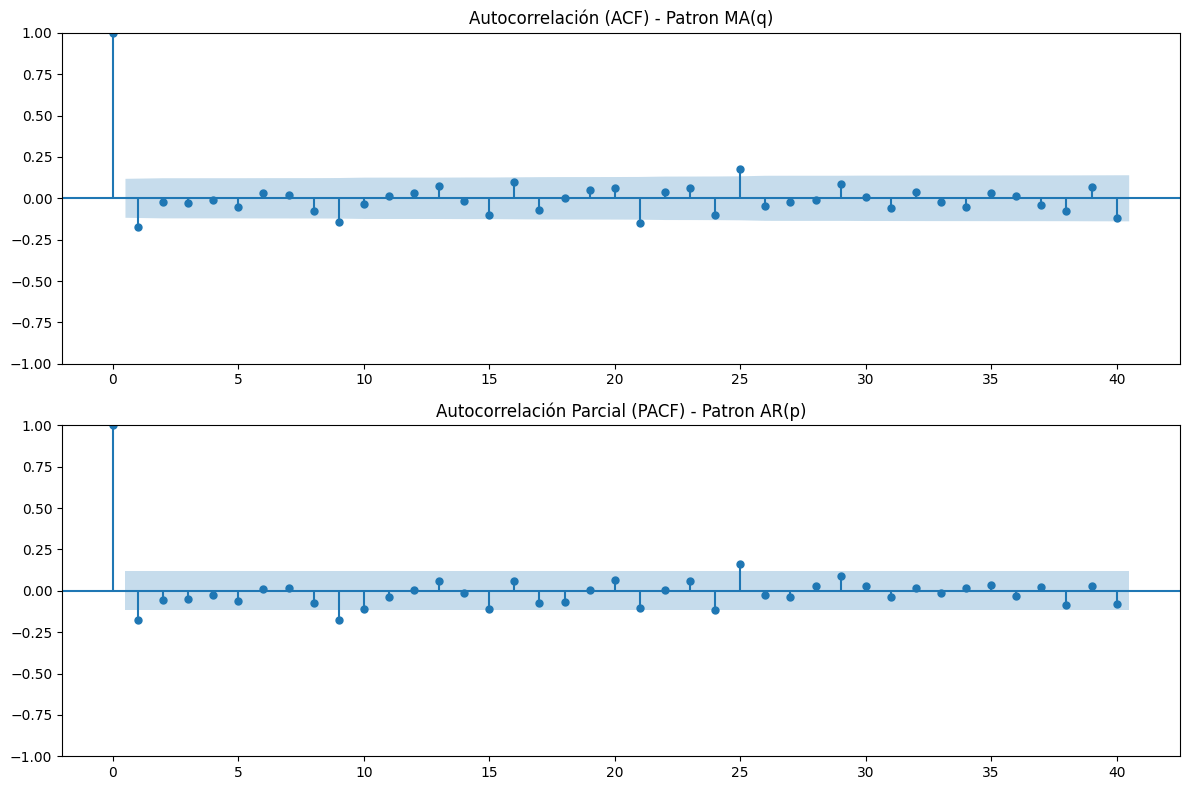

In [27]:
# Prueba de Dickey-Fuller Aumentada (ADF)
def run_adf(series, name):
    result = adfuller(series.dropna())
    print(f'--- Prueba ADF para: {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print("✅ La serie es ESTACIONARIA (Podemos modelar)")
    else:
        print("❌ La serie NO es estacionaria (Necesita más diferenciación)")

print("Resultados de Estacionariedad:")
run_adf(train_df['diff_1'], "Valor con 1era Diferenciación")

# Usamos la serie diferenciada porque es la que entra al modelo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train_df['diff_1'].dropna(), lags=40, ax=ax1, title="Autocorrelación (ACF) - Patron MA(q)")
plot_pacf(train_df['diff_1'].dropna(), lags=40, ax=ax2, title="Autocorrelación Parcial (PACF) - Patron AR(p)")
plt.tight_layout()
plt.show()

## <font color= #70A9E0> &ensp; • **Orden P, Q, s** </font>

# <font color= #99C8F5> **Modelado** </font>

In [96]:

# Definir y ajustar el modelo SARIMAX con parámetros elegidos
# (p,d,q)=(1,1,1) y (P,D,Q,s)=(1,1,1,5) en este ejemplo
modelo = SARIMAX(datos['Valor'], order=(1,1,1), seasonal_order=(1,1,1,5))
resultado = modelo.fit(disp=False)
print(resultado.summary())  # Resumen del ajuste (AIC, coeficientes, etc.)


/home/vivienne/anaconda3/envs/time-series/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/home/vivienne/anaconda3/envs/time-series/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



                                     SARIMAX Results                                     
Dep. Variable:                             Valor   No. Observations:                 8621
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 5)   Log Likelihood                7063.243
Date:                           Mon, 02 Mar 2026   AIC                         -14116.486
Time:                                   21:38:18   BIC                         -14081.180
Sample:                                        0   HQIC                        -14104.446
                                          - 8621                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1972      0.110     -1.785      0.074      -0.414       0.019
ma.L1          0.2313      0.109      2.117

In [97]:
# Predecir los próximos 9 días (5 al 13 de marzo de 2026)
pronostico = resultado.get_forecast(steps=9)
pred_mean = pronostico.predicted_mean

# Crear índice de fechas para el pronóstico (a partir del último día observado)
fechas_pred = pd.date_range(start=datos.index[-1] + pd.Timedelta(days=1), periods=9, freq='D')

# Crear DataFrame con Fecha y Pronóstico
df_pred = pd.DataFrame({'Fecha': fechas_pred, 'Pronóstico': pred_mean.values})

# Exportar las predicciones a un archivo Excel
df_pred.to_excel("predicciones_mar5_13_2026.xlsx", index=False)


/home/vivienne/anaconda3/envs/time-series/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/home/vivienne/anaconda3/envs/time-series/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



In [98]:

fig = go.Figure()
# Serie histórica observada
fig.add_trace(go.Scatter(x=datos.index, y=datos['Valor'], mode='lines', name='Observado'))
# Pronóstico futuro
fig.add_trace(go.Scatter(x=df_pred['Fecha'], y=df_pred['Pronóstico'], mode='lines', name='Pronóstico'))
fig.update_layout(title='Tipo de cambio MXN/USD (FIX): Observado vs Pronóstico',
                  xaxis_title='Fecha', yaxis_title='Tipo de cambio (FIX)')
fig.show()
